3.	Build a Decision Tree & Random Forest model on the fraud data. 
Treat those who have taxable_income <= 30000 as Risky and others as Good (discretize the taxable )
classfication of person salary is good or bad

In [160]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.tree import plot_tree 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report ,f1_score,recall_score,precision_score

In [88]:
df=pd.read_csv("E:/Data Science/13-Decision Tree/Fraud_check.csv")
df

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban
0,NO,Single,68833,50047,10,YES
1,YES,Divorced,33700,134075,18,YES
2,NO,Married,36925,160205,30,YES
3,YES,Single,50190,193264,15,YES
4,NO,Married,81002,27533,28,NO
...,...,...,...,...,...,...
595,YES,Divorced,76340,39492,7,YES
596,YES,Divorced,69967,55369,2,YES
597,NO,Divorced,47334,154058,0,YES
598,YES,Married,98592,180083,17,NO


In [89]:
df.shape

(600, 6)

In [91]:
df['Taxable.Income'][df['Taxable.Income'] <=30000] =True

C:\Users\samir\AppData\Local\Temp\ipykernel_2528\1255118567.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Taxable.Income'][df['Taxable.Income'] <=30000] =True
C:\Users\samir\AppData\Local\Temp\ipykernel_2528\1255118567.py:1: Settin

In [94]:
set(df['Marital.Status'])

{'Divorced', 'Married', 'Single'}

In [95]:
set(df['Undergrad'])

{'NO', 'YES'}

In [98]:
set(df['Urban'])

{'NO', 'YES'}

In [100]:
df.sample(4)

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban
306,YES,Divorced,88918,185099,12,NO
275,YES,Married,86208,55591,0,YES
258,NO,Divorced,92997,74119,28,YES
200,YES,Single,61906,162777,17,YES


In [101]:
df['Taxable.Income'][df['Taxable.Income'] >30000] =False  

In [104]:
df.sample(4)

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban
445,NO,Divorced,False,128451,12,NO
17,YES,Married,False,57194,25,NO
501,NO,Divorced,False,55842,4,YES
11,NO,Single,False,94875,6,YES


In [105]:
df['Taxable.Income']=df['Taxable.Income'].replace(True,'Good')

In [108]:
df.sample(3)

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban
315,YES,Divorced,Good,176278,19,NO
362,YES,Divorced,Good,75552,17,YES
398,NO,Married,Good,64070,2,YES


In [110]:
df['Taxable.Income']=df['Taxable.Income'].replace(False,'Bad')

In [112]:
df.sample(5)

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban
273,YES,Divorced,Bad,58942,20,NO
140,YES,Married,Good,93390,4,YES
588,YES,Married,Bad,93242,27,YES
458,YES,Single,Good,110892,18,YES
195,YES,Single,Bad,181370,13,YES


In [114]:
lab=LabelEncoder()

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Undergrad        600 non-null    object
 1   Marital.Status   600 non-null    object
 2   Taxable.Income   600 non-null    object
 3   City.Population  600 non-null    int64 
 4   Work.Experience  600 non-null    int64 
 5   Urban            600 non-null    object
dtypes: int64(2), object(4)
memory usage: 28.3+ KB


In [118]:
df['Undergrad']=lab.fit_transform(df['Undergrad'])

In [120]:
df['Urban']=lab.fit_transform(df['Urban'])

In [122]:
df['Taxable.Income']=lab.fit_transform(df['Taxable.Income'])

In [124]:
df['Marital.Status']=lab.fit_transform(df['Marital.Status'])

<Axes: xlabel='City.Population', ylabel='Work.Experience'>

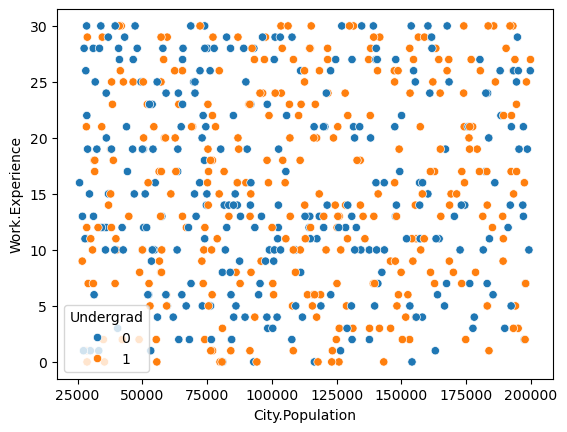

In [126]:
sns.scatterplot(df,x='City.Population',y='Work.Experience',hue='Undergrad')

In [127]:
# city population is not import in given  table  

In [128]:
df=df.drop(columns=['City.Population'])

In [132]:
df['Taxable.Income'].value_counts()

Taxable.Income
0    476
1    124
Name: count, dtype: int64

In [134]:
# imblace data 


In [136]:
X=df.iloc[:,[0,1,3,4]]
y=df['Taxable.Income'].values

In [138]:
 X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [140]:
clf1=DecisionTreeClassifier()
clf2=RandomForestClassifier()

In [142]:
clf1.fit(X_train,y_train)

DecisionTreeClassifier()

In [147]:
clf2.fit(X_train,y_train)

RandomForestClassifier()

In [151]:
 y_pre1=clf1.predict(X_test)
y_pre2=clf2.predict(X_test)  

In [153]:
accuracy_score(y_pre1,y_test)

0.7416666666666667

In [155]:
accuracy_score(y_pre2,y_test)

0.7333333333333333

DecisionTreeClassifier ---> having more accuray then the random forest
checking classfication report to anylis the overfiting condition in given data

In [162]:
print(classification_report(y_test,y_pre1))

              precision    recall  f1-score   support

           0       0.79      0.90      0.85        94
           1       0.31      0.15      0.21        26

    accuracy                           0.74       120
   macro avg       0.55      0.53      0.53       120
weighted avg       0.69      0.74      0.71       120



In [164]:
print(classification_report(y_test,y_pre2))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84        94
           1       0.25      0.12      0.16        26

    accuracy                           0.73       120
   macro avg       0.52      0.51      0.50       120
weighted avg       0.67      0.73      0.69       120



In [166]:
recall_score(y_test,y_pre1)

0.15384615384615385

In [168]:
f1_score(y_test,y_pre1)

0.20512820512820512